In [2]:

import cv2
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from collections import deque


# Output folder
OUT = Path("outputs(23k0052)")
OUT.mkdir(exist_ok=True)


# ---------------------------------------------------------
# Load images only once
# ---------------------------------------------------------

# Sudoku image
sudoku = cv2.imread("sudoku.png", cv2.IMREAD_GRAYSCALE)

if sudoku is None:
    raise FileNotFoundError(
        "Place sudoku.png in the notebook folder."
    )


# Smarties image
smarties_bgr = cv2.imread("smarties.png")

if smarties_bgr is None:
    raise FileNotFoundError(
        "Place smarties.png in the notebook folder."
    )

smarties_rgb = cv2.cvtColor(
    smarties_bgr,
    cv2.COLOR_BGR2RGB
)


# Touching coins image
coins_bgr = cv2.imread("coins(1).png")

if coins_bgr is None:
    raise FileNotFoundError(
        "Place coins(1).png in the notebook folder."
    )

coins_rgb = cv2.cvtColor(
    coins_bgr,
    cv2.COLOR_BGR2RGB
)

coins_gray = cv2.cvtColor(
    coins_bgr,
    cv2.COLOR_BGR2GRAY
)


# Brain MRI image
brain_gray = cv2.imread(
    "mri.png",
    cv2.IMREAD_GRAYSCALE
)

if brain_gray is None:
    raise FileNotFoundError(
        "Place brain_mri.png in the notebook folder."
    )


# Dog image
dog_bgr = cv2.imread("dog.jpeg")

if dog_bgr is None:
    raise FileNotFoundError(
        "Place dog.jpeg in the notebook folder."
    )

dog_rgb = cv2.cvtColor(
    dog_bgr,
    cv2.COLOR_BGR2RGB
)


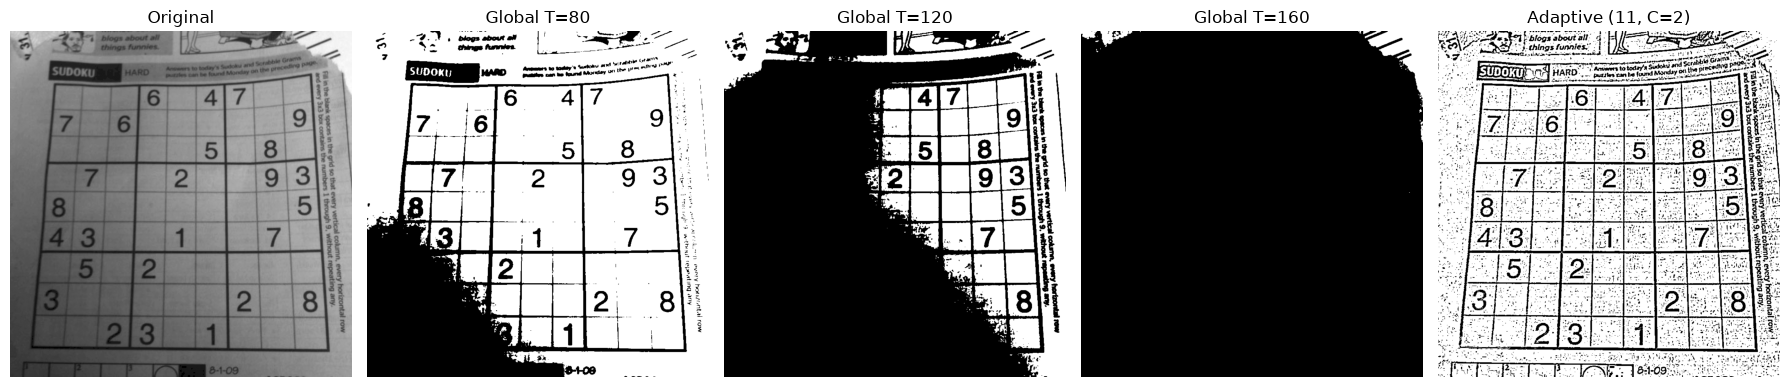

True

In [3]:
# =========================================================
# TASK 1 - GLOBAL AND ADAPTIVE THRESHOLDING
# =========================================================

# Define threshold values for global thresholding
thresholds = [80, 120, 160]

# Store the thresholded images
global_results = []

# Apply global thresholding using each threshold value
for t in thresholds:
    _, mask = cv2.threshold(
        sudoku,
        t,
        255,
        cv2.THRESH_BINARY
    )

    global_results.append(mask)


# Apply adaptive Gaussian thresholding
adaptive = cv2.adaptiveThreshold(
    sudoku,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)


# Display all results
fig, ax = plt.subplots(
    1,
    5,
    figsize=(18, 5)
)

items = [
    ("Original", sudoku)
] + [
    (f"Global T={t}", mask)
    for t, mask in zip(thresholds, global_results)
] + [
    ("Adaptive (11, C=2)", adaptive)
]

for a, (title, image) in zip(ax, items):
    a.imshow(image, cmap="gray")
    a.set_title(title)
    a.axis("off")

plt.tight_layout()
plt.show()


# Save final result
cv2.imwrite(
    str(OUT / "task1_final.png"),
    adaptive
)


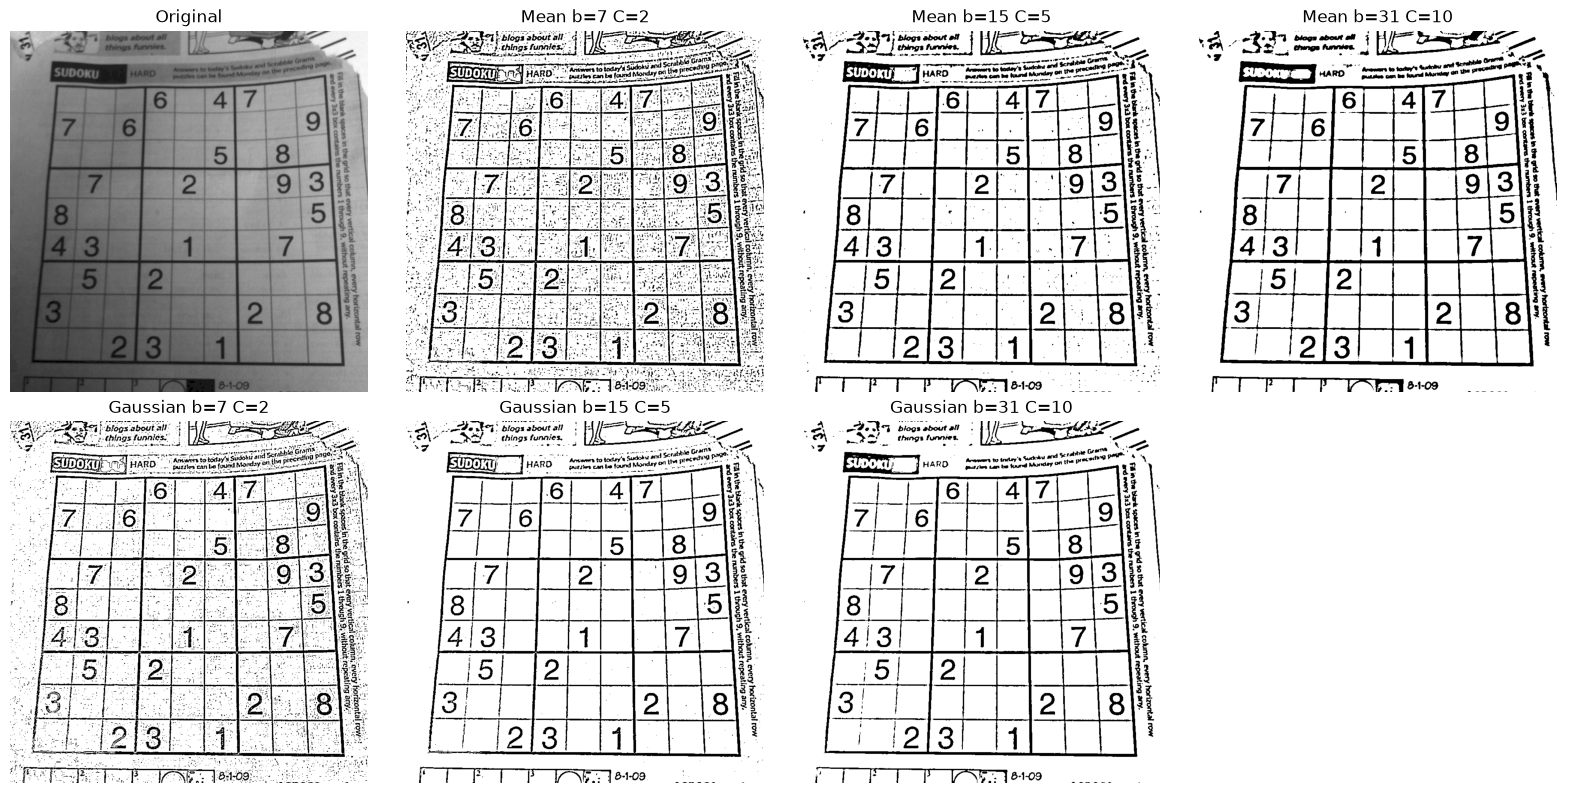

True

In [4]:
# =========================================================
# TASK 2 - ADAPTIVE THRESHOLDING COMPARISON
# =========================================================

# Define adaptive thresholding configurations
configs = [
    ("Mean", cv2.ADAPTIVE_THRESH_MEAN_C, 7, 2),
    ("Mean", cv2.ADAPTIVE_THRESH_MEAN_C, 15, 5),
    ("Mean", cv2.ADAPTIVE_THRESH_MEAN_C, 31, 10),
    ("Gaussian", cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 7, 2),
    ("Gaussian", cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 15, 5),
    ("Gaussian", cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 31, 10)
]

# Store thresholding results
results = []

# Apply each configuration
for name, method, block, c in configs:
    thresholded = cv2.adaptiveThreshold(
        sudoku,
        255,
        method,
        cv2.THRESH_BINARY,
        block,
        c
    )

    results.append(
        (f"{name} b={block} C={c}", thresholded)
    )


# Create display grid
fig, ax = plt.subplots(
    2,
    4,
    figsize=(16, 8)
)

ax = ax.ravel()

# Display original image
ax[0].imshow(sudoku, cmap="gray")
ax[0].set_title("Original")
ax[0].axis("off")


# Display all results
for a, (title, image) in zip(
    ax[1:],
    results
):
    a.imshow(image, cmap="gray")
    a.set_title(title)
    a.axis("off")


# Hide unused subplot
ax[-1].axis("off")

plt.tight_layout()
plt.show()


# Save the selected result
cv2.imwrite(
    str(OUT / "task2_final.png"),
    results[4][1]
)


Otsu original threshold: 162.0
Otsu after CLAHE: 157.0


C:\Users\Hp Elitebook 840 G3\AppData\Local\Temp\ipykernel_12024\890760311.py:53: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  ax[1].hist(


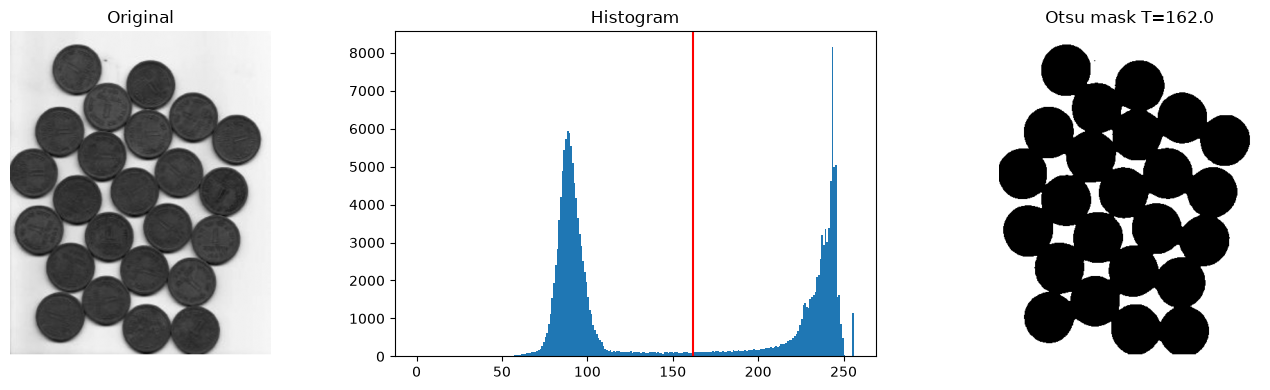

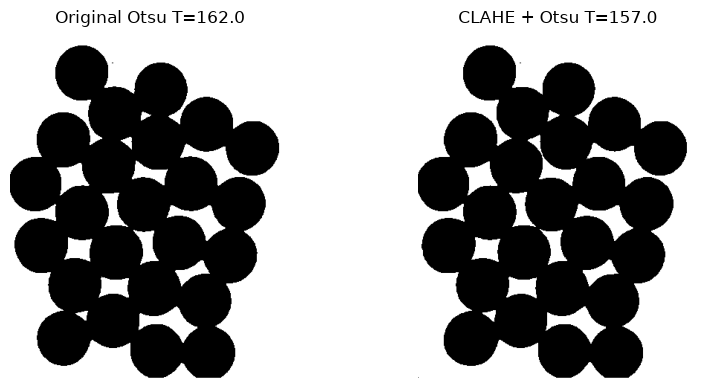

True

In [5]:
# =========================================================
# TASK 3 - OTSU THRESHOLDING + CLAHE
# =========================================================

# Function for Otsu thresholding
def otsu(image):
    threshold, mask = cv2.threshold(
        image,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    return threshold, mask


# Apply Otsu to the original image
t1, m1 = otsu(coins_gray)


# Apply CLAHE for local contrast enhancement
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

clahe_image = clahe.apply(coins_gray)


# Apply Otsu after CLAHE
t2, m2 = otsu(clahe_image)


# Print threshold values
print(f"Otsu original threshold: {t1:.1f}")
print(f"Otsu after CLAHE: {t2:.1f}")


# Display original, histogram, and Otsu mask
fig, ax = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)

ax[0].imshow(
    coins_gray,
    cmap="gray"
)
ax[0].set_title("Original")


ax[1].hist(
    coins_gray.ravel(),
    256,
    [0, 256]
)
ax[1].axvline(
    t1,
    color="red"
)
ax[1].set_title("Histogram")


ax[2].imshow(
    m1,
    cmap="gray"
)
ax[2].set_title(
    f"Otsu mask T={t1:.1f}"
)


for a in [ax[0], ax[2]]:
    a.axis("off")

plt.tight_layout()
plt.show()


# Compare original Otsu with CLAHE + Otsu
fig, ax = plt.subplots(
    1,
    2,
    figsize=(9, 4)
)

ax[0].imshow(
    m1,
    cmap="gray"
)
ax[0].set_title(
    f"Original Otsu T={t1:.1f}"
)

ax[1].imshow(
    m2,
    cmap="gray"
)
ax[1].set_title(
    f"CLAHE + Otsu T={t2:.1f}"
)

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()


# Save final result
cv2.imwrite(
    str(OUT / "task3_final.png"),
    m1
)


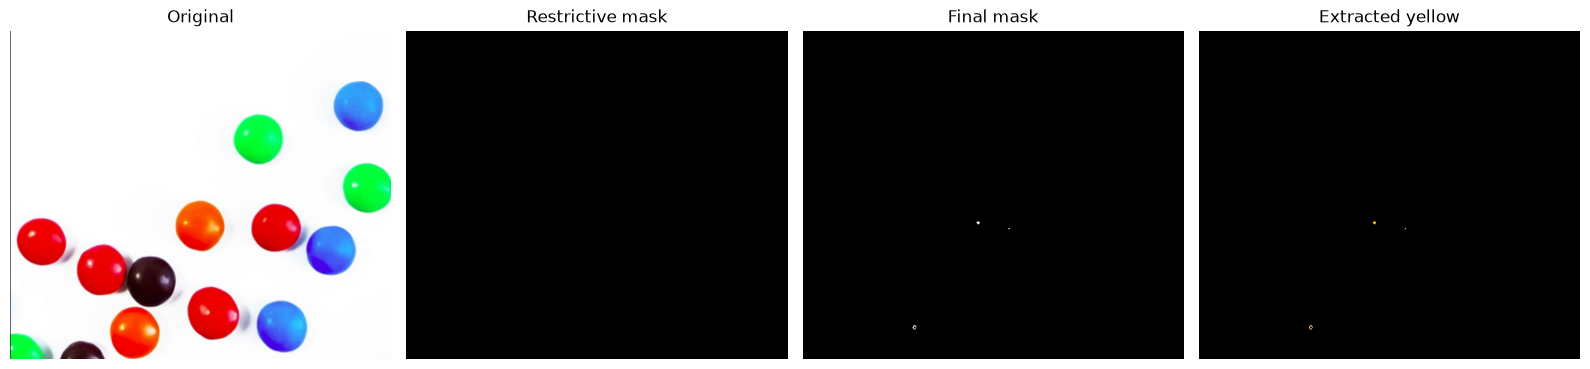

True

In [6]:
# =========================================================
# TASK 4 - HSV COLOR SEGMENTATION
# =========================================================

# Convert Smarties image to HSV
hsv = cv2.cvtColor(
    smarties_bgr,
    cv2.COLOR_BGR2HSV
)


# Restrictive yellow mask
restrict = cv2.inRange(
    hsv,
    np.array([27, 180, 180]),
    np.array([30, 255, 255])
)


# Broader yellow mask
final = cv2.inRange(
    hsv,
    np.array([20, 100, 100]),
    np.array([35, 255, 255])
)


# Extract yellow regions
extracted = cv2.bitwise_and(
    smarties_bgr,
    smarties_bgr,
    mask=final
)


# Convert extracted image to RGB
extracted = cv2.cvtColor(
    extracted,
    cv2.COLOR_BGR2RGB
)


# Display results
fig, ax = plt.subplots(
    1,
    4,
    figsize=(16, 4)
)

items = [
    ("Original", smarties_rgb),
    ("Restrictive mask", restrict),
    ("Final mask", final),
    ("Extracted yellow", extracted)
]

for a, (title, image) in zip(ax, items):
    a.imshow(
        image,
        cmap="gray" if image.ndim == 2 else None
    )
    a.set_title(title)
    a.axis("off")

plt.tight_layout()
plt.show()


# Save final mask
cv2.imwrite(
    str(OUT / "task4_final_mask.png"),
    final
)


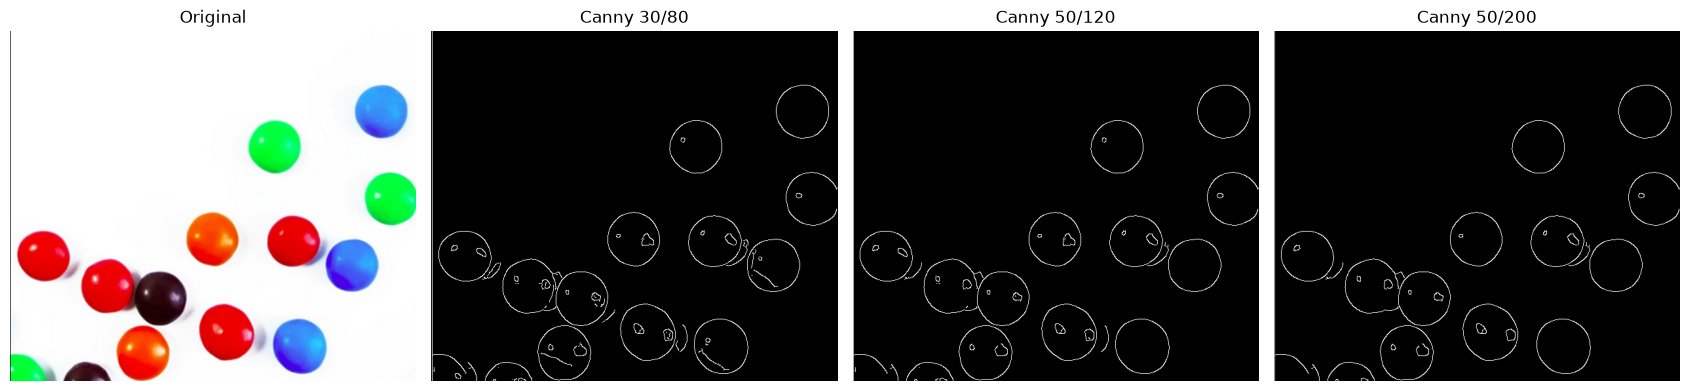

True

In [7]:
# =========================================================
# TASK 5 - CANNY EDGE DETECTION
# =========================================================

# Convert Smarties image to grayscale
gray = cv2.cvtColor(
    smarties_bgr,
    cv2.COLOR_BGR2GRAY
)


# Apply Gaussian blur to reduce noise
blur = cv2.GaussianBlur(
    gray,
    (5, 5),
    1
)


# Define Canny threshold pairs
pairs = [
    (30, 80),
    (50, 120),
    (50, 200)
]


# Apply Canny edge detection
edges = [
    cv2.Canny(
        blur,
        low,
        high
    )
    for low, high in pairs
]


# Display results
fig, ax = plt.subplots(
    1,
    4,
    figsize=(17, 4)
)

ax[0].imshow(smarties_rgb)
ax[0].set_title("Original")
ax[0].axis("off")


for a, (thresholds, edge) in zip(
    ax[1:],
    zip(pairs, edges)
):
    a.imshow(
        edge,
        cmap="gray"
    )
    a.set_title(
        f"Canny {thresholds[0]}/{thresholds[1]}"
    )
    a.axis("off")

plt.tight_layout()
plt.show()


# Save the second Canny result
cv2.imwrite(
    str(OUT / "task5_final.png"),
    edges[1]
)


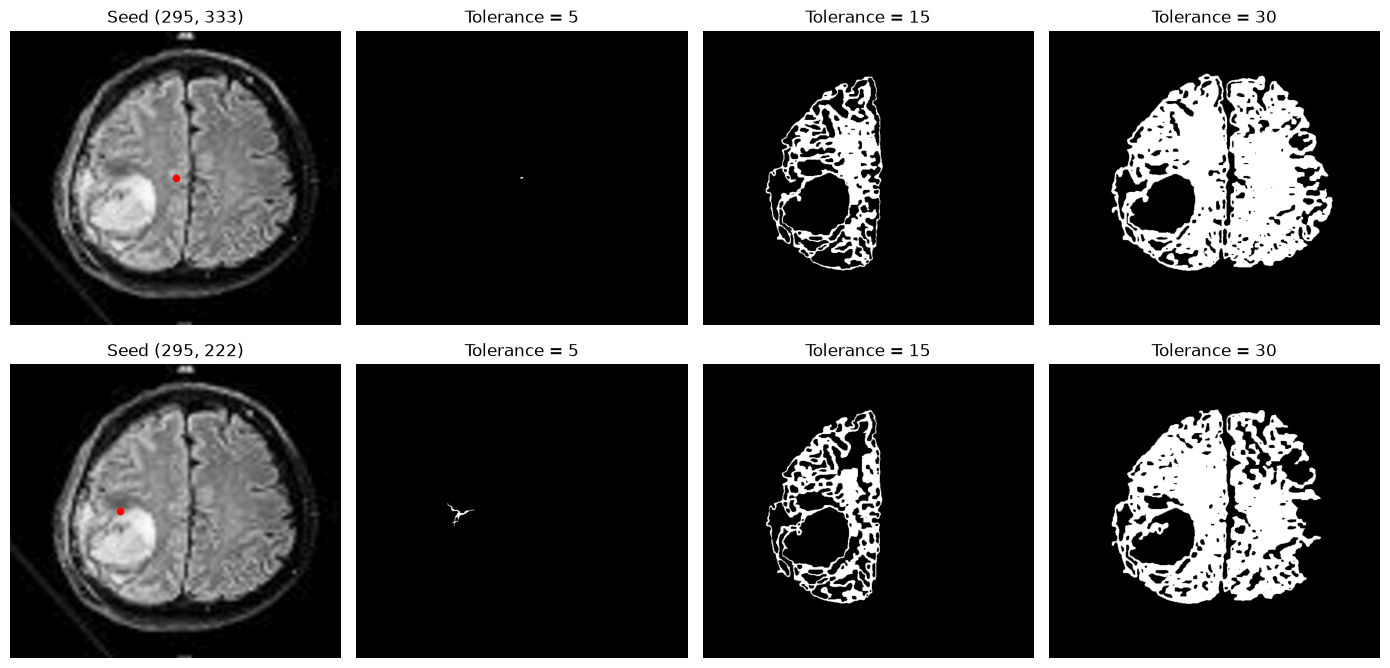

True

In [8]:
# =========================================================
# TASK 6 - REGION GROWING
# =========================================================

def grow(image, seed, tolerance):
    """
    Perform region growing from a given seed point.
    """

    h, w = image.shape

    # Output mask
    mask = np.zeros(
        (h, w),
        np.uint8
    )

    # Track visited pixels
    seen = np.zeros(
        (h, w),
        bool
    )

    # Initialize queue
    queue = deque([seed])

    # Reference intensity from seed
    reference = int(image[seed])

    while queue:
        y, x = queue.popleft()

        # Skip invalid or already visited pixels
        if (
            y < 0
            or y >= h
            or x < 0
            or x >= w
            or seen[y, x]
        ):
            continue

        # Mark pixel as visited
        seen[y, x] = True

        # Check intensity similarity
        if abs(
            int(image[y, x]) - reference
        ) <= tolerance:

            # Add pixel to region
            mask[y, x] = 255

            # Add four-connected neighbors
            queue.extend([
                (y - 1, x),
                (y + 1, x),
                (y, x - 1),
                (y, x + 1)
            ])

    return mask


# Image dimensions
h, w = brain_gray.shape


# Define seed points
seeds = [
    (h // 2, w // 2),
    (h // 2, w // 3)
]


# Define tolerance values
tolerances = [5, 15, 30]


# Display results
fig, ax = plt.subplots(
    2,
    4,
    figsize=(14, 7)
)


for row, seed in enumerate(seeds):

    # Original image with seed
    ax[row, 0].imshow(
        brain_gray,
        cmap="gray"
    )

    ax[row, 0].scatter(
        [seed[1]],
        [seed[0]],
        c="red",
        s=20
    )

    ax[row, 0].set_title(
        f"Seed {seed}"
    )

    ax[row, 0].axis("off")


    # Region growing for each tolerance
    for col, tolerance in enumerate(
        tolerances,
        1
    ):
        mask = grow(
            brain_gray,
            seed,
            tolerance
        )

        ax[row, col].imshow(
            mask,
            cmap="gray"
        )

        ax[row, col].set_title(
            f"Tolerance = {tolerance}"
        )

        ax[row, col].axis("off")


plt.tight_layout()
plt.show()


# Save final result
final = grow(
    brain_gray,
    seeds[0],
    15
)

cv2.imwrite(
    str(OUT / "task6_final.png"),
    final
)


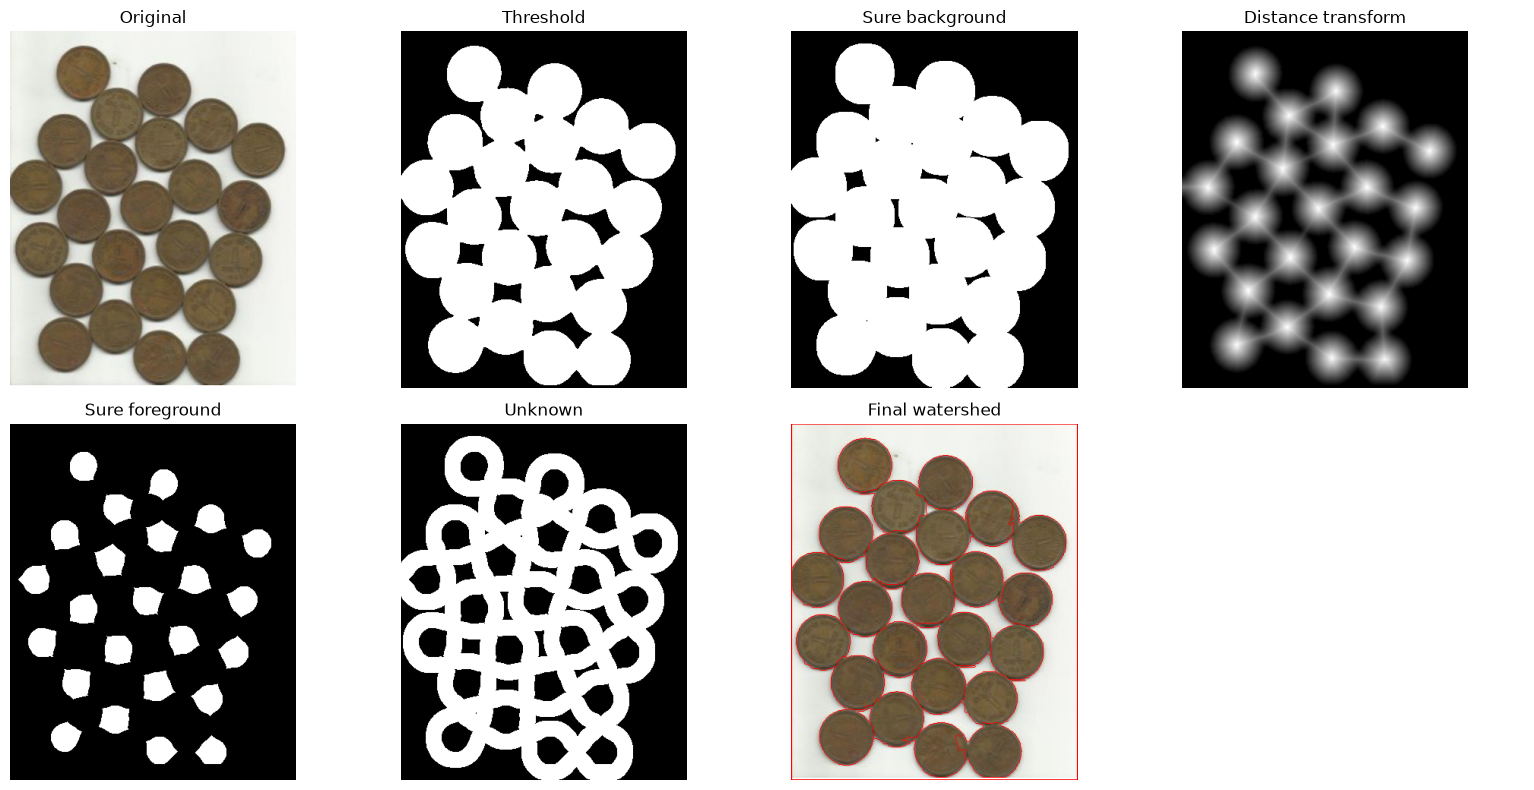

True

In [9]:
# =========================================================
# TASK 7 - WATERSHED SEGMENTATION
# =========================================================

# Apply Gaussian blur
blur = cv2.GaussianBlur(
    coins_gray,
    (5, 5),
    0
)


# Otsu thresholding with binary inversion
_, th = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)


# Create morphological kernel
kernel = np.ones(
    (3, 3),
    np.uint8
)


# Remove small noise
opening = cv2.morphologyEx(
    th,
    cv2.MORPH_OPEN,
    kernel,
    iterations=2
)


# Determine sure background
sure_bg = cv2.dilate(
    opening,
    kernel,
    iterations=3
)


# Distance transform
dist = cv2.distanceTransform(
    opening,
    cv2.DIST_L2,
    5
)


# Determine sure foreground
_, sure_fg = cv2.threshold(
    dist,
    0.5 * dist.max(),
    255,
    0
)

sure_fg = np.uint8(sure_fg)


# Determine unknown region
unknown = cv2.subtract(
    sure_bg,
    sure_fg
)


# Create markers
n, markers = cv2.connectedComponents(
    sure_fg
)

markers = markers + 1

markers[unknown == 255] = 0


# Apply Watershed
markers = cv2.watershed(
    coins_bgr,
    markers
)


# Mark watershed boundaries in red
final = coins_rgb.copy()

final[markers == -1] = [
    255,
    0,
    0
]


# Display processing stages
fig, ax = plt.subplots(
    2,
    4,
    figsize=(16, 8)
)

items = [
    ("Original", coins_rgb),
    ("Threshold", th),
    ("Sure background", sure_bg),
    ("Distance transform", dist),
    ("Sure foreground", sure_fg),
    ("Unknown", unknown),
    ("Final watershed", final)
]

for a, (title, image) in zip(
    ax.ravel(),
    items
):
    a.imshow(
        image,
        cmap="gray" if image.ndim == 2 else None
    )
    a.set_title(title)
    a.axis("off")


# Hide unused subplot
ax.ravel()[-1].axis("off")

plt.tight_layout()
plt.show()


# Save final result
cv2.imwrite(
    str(OUT / "task7_final.png"),
    cv2.cvtColor(
        final,
        cv2.COLOR_RGB2BGR
    )
)


Experiment | Distance threshold | Foreground markers | Separated regions
1 | | | 0.3 | 1 | 1
2 | | | 0.4 | 22 | 22
3 | | | 0.5 | 24 | 24
4 | | | 0.6 | 24 | 24


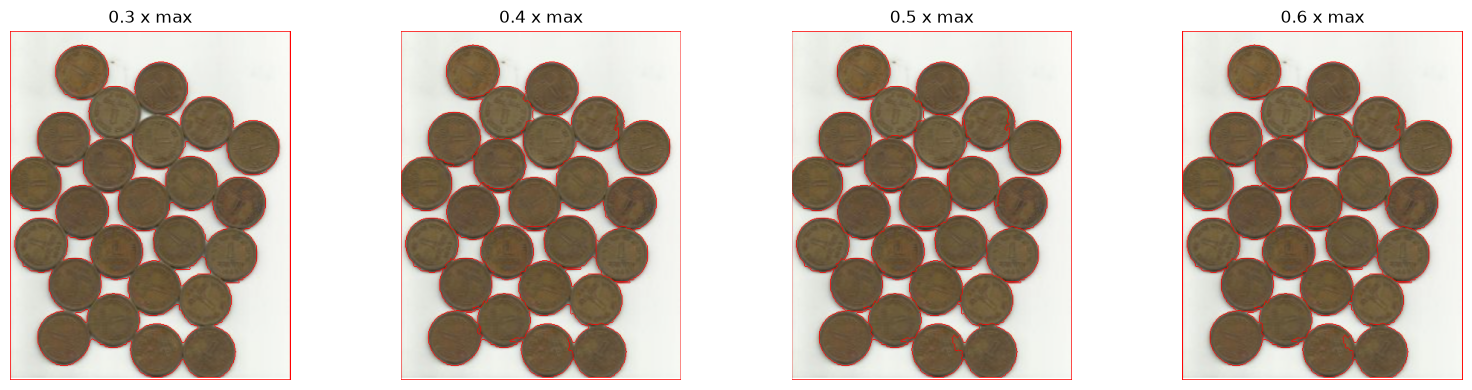

True

In [10]:
# =========================================================
# TASK 8 - WATERSHED PARAMETER EXPERIMENT
# =========================================================

# Apply Gaussian blur
blur = cv2.GaussianBlur(
    coins_gray,
    (5, 5),
    0
)


# Apply Otsu thresholding
_, th = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)


# Morphological kernel
k = np.ones(
    (3, 3),
    np.uint8
)


# Remove small noise
opening = cv2.morphologyEx(
    th,
    cv2.MORPH_OPEN,
    k,
    iterations=2
)


# Determine sure background
bg = cv2.dilate(
    opening,
    k,
    iterations=3
)


# Distance transform
dist = cv2.distanceTransform(
    opening,
    cv2.DIST_L2,
    5
)


# Threshold fractions to test
fractions = [
    0.3,
    0.4,
    0.5,
    0.6
]

rows = []
images = []


# Test each threshold fraction
for fraction in fractions:

    # Create sure foreground
    _, fg = cv2.threshold(
        dist,
        fraction * dist.max(),
        255,
        0
    )

    fg = np.uint8(fg)


    # Find unknown region
    unknown = cv2.subtract(
        bg,
        fg
    )


    # Connected components
    n, markers = cv2.connectedComponents(
        fg
    )

    foreground = n - 1


    # Shift marker labels
    markers = markers + 1


    # Mark unknown region as zero
    markers[unknown == 255] = 0


    # Apply Watershed
    markers = cv2.watershed(
        coins_bgr.copy(),
        markers
    )


    # Count separated regions
    separated = len([
        value
        for value in np.unique(markers)
        if value > 1
    ])


    # Visualize watershed boundaries
    vis = coins_rgb.copy()

    vis[markers == -1] = [
        255,
        0,
        0
    ]


    images.append(vis)

    rows.append(
        (
            fraction,
            foreground,
            separated
        )
    )


# Print experiment results
print(
    "Experiment | Distance threshold | "
    "Foreground markers | Separated regions"
)

for i, row in enumerate(rows, 1):
    print(
        i,
        "|",
        *row,
        sep=" | "
    )


# Display results
fig, ax = plt.subplots(
    1,
    4,
    figsize=(16, 4)
)

for a, fraction, image in zip(
    ax,
    fractions,
    images
):
    a.imshow(image)
    a.set_title(
        f"{fraction:.1f} x max"
    )
    a.axis("off")

plt.tight_layout()
plt.show()


# Save the 0.5 result
cv2.imwrite(
    str(OUT / "task8_final.png"),
    cv2.cvtColor(
        images[2],
        cv2.COLOR_RGB2BGR
    )
)


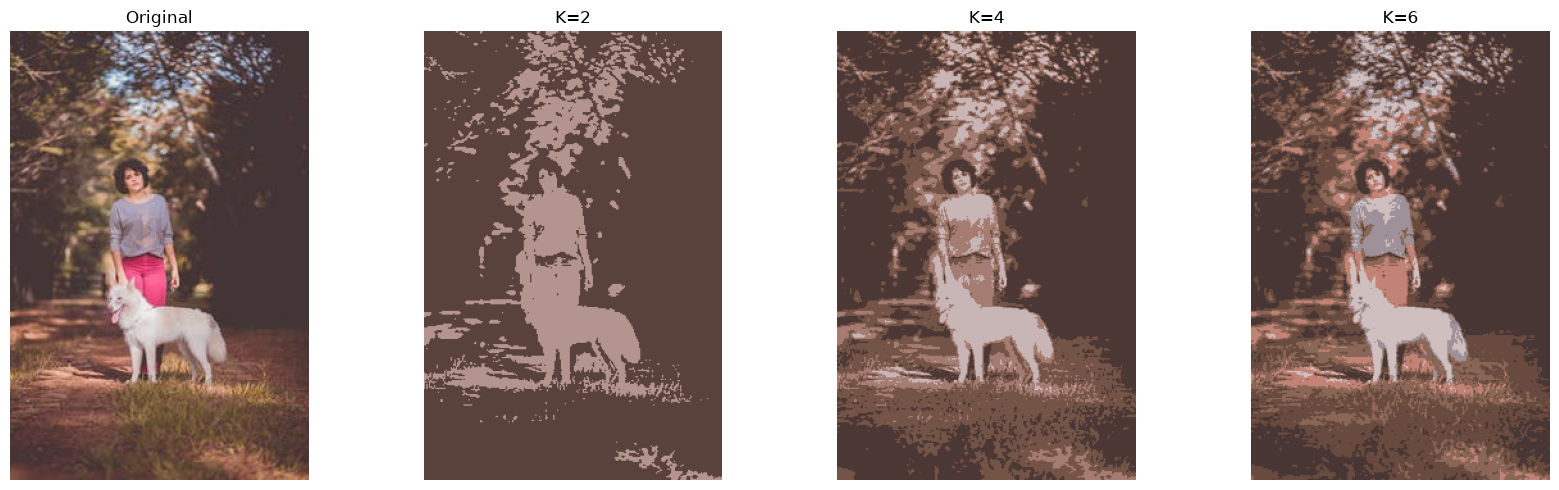

True

In [11]:
# =========================================================
# TASK 9 - K-MEANS IMAGE SEGMENTATION
# =========================================================

# Reshape RGB image into a list of pixels
data = np.float32(
    dog_rgb.reshape((-1, 3))
)


# Define K-Means termination criteria
criteria = (
    cv2.TERM_CRITERIA_EPS
    + cv2.TERM_CRITERIA_MAX_ITER,
    100,
    0.2
)


# K-Means segmentation function
def segment(K):
    """
    Segment the dog image using K-Means clustering.
    """

    # Set fixed seed for reproducibility
    cv2.setRNGSeed(42)

    # Perform K-Means clustering
    _, labels, centers = cv2.kmeans(
        data,
        K,
        None,
        criteria,
        10,
        cv2.KMEANS_PP_CENTERS
    )


    # Convert cluster centers to 8-bit
    centers = np.uint8(centers)


    # Replace each pixel with its cluster center
    segmented = centers[
        labels.flatten()
    ].reshape(dog_rgb.shape)

    return segmented


# Test different K values
Ks = [
    2,
    4,
    6
]

results = [
    segment(k)
    for k in Ks
]


# Display results
fig, ax = plt.subplots(
    1,
    4,
    figsize=(17, 5)
)


ax[0].imshow(dog_rgb)
ax[0].set_title("Original")
ax[0].axis("off")


for a, k, image in zip(
    ax[1:],
    Ks,
    results
):
    a.imshow(image)
    a.set_title(f"K={k}")
    a.axis("off")


plt.tight_layout()
plt.show()


# Save K=6 result
cv2.imwrite(
    str(OUT / "task9_final_k6.png"),
    cv2.cvtColor(
        results[-1],
        cv2.COLOR_RGB2BGR
    )
)


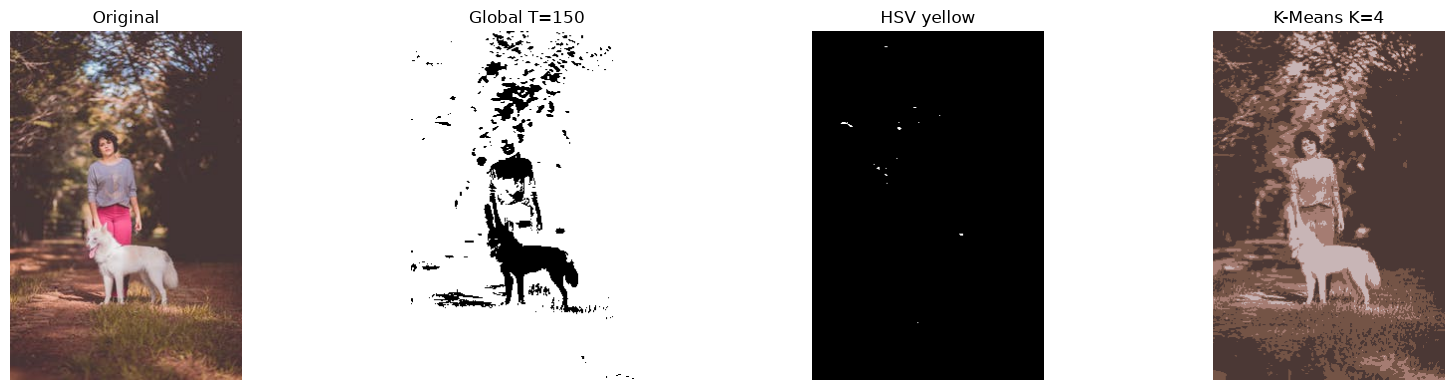

True

In [12]:
# =========================================================
# TASK 10 - SEGMENTATION METHOD COMPARISON
# =========================================================

# Convert dog image to grayscale
gray = cv2.cvtColor(
    dog_bgr,
    cv2.COLOR_BGR2GRAY
)


# ---------------------------------------------------------
# Global Thresholding
# ---------------------------------------------------------

_, global_mask = cv2.threshold(
    gray,
    150,
    255,
    cv2.THRESH_BINARY_INV
)


# ---------------------------------------------------------
# HSV Segmentation
# ---------------------------------------------------------

# Convert dog image to HSV
hsv = cv2.cvtColor(
    dog_bgr,
    cv2.COLOR_BGR2HSV
)


# Define yellow HSV range
lower_yellow = np.array([
    20,
    100,
    100
])

upper_yellow = np.array([
    35,
    255,
    255
])


# Create yellow mask
hsv_mask = cv2.inRange(
    hsv,
    lower_yellow,
    upper_yellow
)


# ---------------------------------------------------------
# K-Means Segmentation
# ---------------------------------------------------------

# Reshape RGB pixels
data = np.float32(
    dog_rgb.reshape(-1, 3)
)


# K-Means criteria
criteria = (
    cv2.TERM_CRITERIA_EPS
    + cv2.TERM_CRITERIA_MAX_ITER,
    100,
    0.2
)


# Fixed seed for reproducibility
cv2.setRNGSeed(42)


# Apply K-Means with K=4
_, labels, centers = cv2.kmeans(
    data,
    4,
    None,
    criteria,
    10,
    cv2.KMEANS_PP_CENTERS
)


# Convert centers to 8-bit
centers = np.uint8(centers)


# Reconstruct segmented image
km = centers[
    labels.flatten()
].reshape(dog_rgb.shape)


# ---------------------------------------------------------
# Display Comparison
# ---------------------------------------------------------

fig, ax = plt.subplots(
    1,
    4,
    figsize=(17, 4)
)

items = [
    ("Original", dog_rgb),
    ("Global T=150", global_mask),
    ("HSV yellow", hsv_mask),
    ("K-Means K=4", km)
]


for a, (title, image) in zip(
    ax,
    items
):
    a.imshow(
        image,
        cmap="gray" if image.ndim == 2 else None
    )
    a.set_title(title)
    a.axis("off")


plt.tight_layout()
plt.show()


# Save HSV segmentation mask
cv2.imwrite(
    str(OUT / "task10_final_hsv.png"),
    hsv_mask
)
